# Anomaly Detection: MNIST vs Fashion-MNIST

The autoencoder was trained to **denoise** MNIST digits — given a noisy input, it should
produce a clean output. We use this at inference by adding the same Gaussian noise
(`factor = 0.4`) to both MNIST and Fashion-MNIST test images, then measure:

$$ \text{MSE} = \|x_{\text{clean}} - \text{AE}(x_{\text{noisy}})\|^2 $$

- **MNIST:** AE was trained on these, so it can denoise well → low MSE
- **Fashion-MNIST:** AE has never seen clothes — it can't denoise toward a valid target → high MSE

This matches how the model was trained (noisy → clean)

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

BATCH_SIZE = 128
NOISE_FACTOR = 0.4  # same as used when training the denoising AE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Load the Trained Autoencoder

In [11]:
CONVOLUTION_CHANNEL_AMOUNT = 7

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # is a convolution so takes ENTIRE image and only requires channels so -> (1, 32, 7, 7), 1 is the input chanels so 1 for black and white, 3 for RGB, 32 is the output channels
            nn.Conv2d(1, CONVOLUTION_CHANNEL_AMOUNT, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(CONVOLUTION_CHANNEL_AMOUNT, CONVOLUTION_CHANNEL_AMOUNT, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(CONVOLUTION_CHANNEL_AMOUNT, CONVOLUTION_CHANNEL_AMOUNT, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(CONVOLUTION_CHANNEL_AMOUNT, CONVOLUTION_CHANNEL_AMOUNT, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(CONVOLUTION_CHANNEL_AMOUNT, 1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder().to(device)
model.load_state_dict(torch.load("denoising_ae.pth", map_location=device))
model.eval()
print("Autoencoder loaded.")

Autoencoder loaded.


## 2. Load Normal (MNIST) and Anomaly (Fashion-MNIST)

In [12]:
to_tensor = transforms.ToTensor()
normal_ds = datasets.MNIST("data", train=False, download=True, transform=to_tensor)
anomaly_ds = datasets.FashionMNIST("data", train=False, download=True, transform=to_tensor)

normal_loader = DataLoader(normal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
anomaly_loader = DataLoader(anomaly_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Normal  (MNIST):         {len(normal_ds)} images")
print(f"Anomaly (Fashion-MNIST): {len(anomaly_ds)} images")

Normal  (MNIST):         10000 images
Anomaly (Fashion-MNIST): 10000 images


## 3. Compute Denoising Error

Add noise, pass through the AE, measure MSE between the AE's output and the clean target.

In [13]:
def add_noise(images, factor=NOISE_FACTOR):
    noisy = images + factor * torch.randn_like(images)
    return noisy.clamp(0, 1)

def compute_denoise_errors(model, loader):
    """Add noise, denoise, compute MSE between denoised output and clean input."""
    errors, all_clean, all_noisy, all_recons = [], [], [], []
    torch.manual_seed(0)  # reproducible noise
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy = add_noise(images)
            recon = model(noisy)
            mse = (images - recon).pow(2).mean(dim=[1, 2, 3])  # clean vs denoised
            errors.append(mse.cpu())
            all_clean.append(images.cpu())
            all_noisy.append(noisy.cpu())
            all_recons.append(recon.cpu())
    return torch.cat(errors), torch.cat(all_clean), torch.cat(all_noisy), torch.cat(all_recons)

normal_errors, normal_clean, normal_noisy, normal_recons = compute_denoise_errors(model, normal_loader)
anomaly_errors, anomaly_clean, anomaly_noisy, anomaly_recons = compute_denoise_errors(model, anomaly_loader)

print(f"Normal  (MNIST):         Mean MSE = {normal_errors.mean():.6f} ± {normal_errors.std():.6f}")
print(f"Anomaly (Fashion-MNIST): Mean MSE = {anomaly_errors.mean():.6f} ± {anomaly_errors.std():.6f}")
print(f"Ratio (anomaly/normal):  {anomaly_errors.mean() / normal_errors.mean():.2f}x")

Normal  (MNIST):         Mean MSE = 0.011336 ± 0.004175
Anomaly (Fashion-MNIST): Mean MSE = 0.030379 ± 0.012013
Ratio (anomaly/normal):  2.68x


## 4. Reconstruction Error Distribution

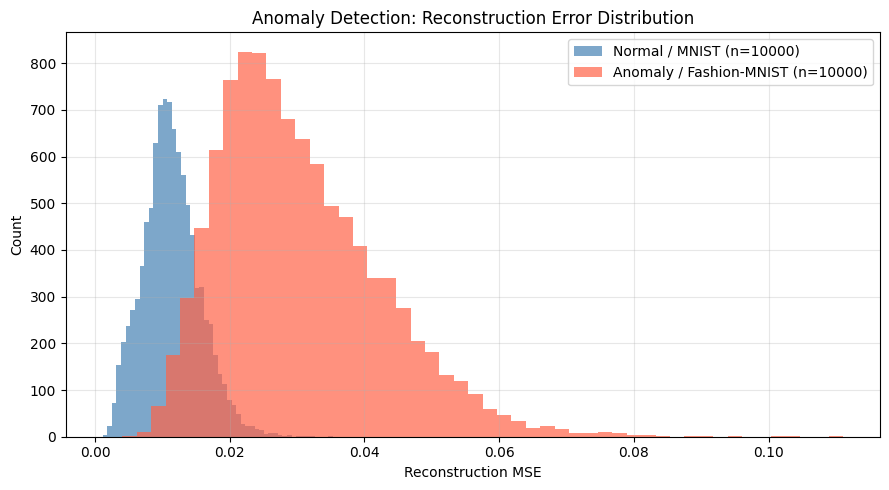

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(normal_errors.numpy(), bins=50, alpha=0.7,
        label=f"Normal / MNIST (n={len(normal_errors)})", color='steelblue')
ax.hist(anomaly_errors.numpy(), bins=50, alpha=0.7,
        label=f"Anomaly / Fashion-MNIST (n={len(anomaly_errors)})", color='tomato')
ax.set_xlabel("Reconstruction MSE")
ax.set_ylabel("Count")
ax.set_title("Anomaly Detection: Reconstruction Error Distribution")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Threshold-Based Anomaly Detection

Pick a cutoff value for the reconstruction MSE — anything above it we flag as anomaly.

We use the **95th percentile of normal errors** as threshold. This is a natural choice: it accepts a
5% false alarm rate on known-normal data. Then we check how many actual anomalies are above the line.

Threshold (95th percentile of normal): 0.018611

  Normal  (MNIST):           500 / 10000 above threshold  (5.0% false alarm)
  Anomaly (Fashion-MNIST):  8523 / 10000 above threshold  (85.2% detection rate)


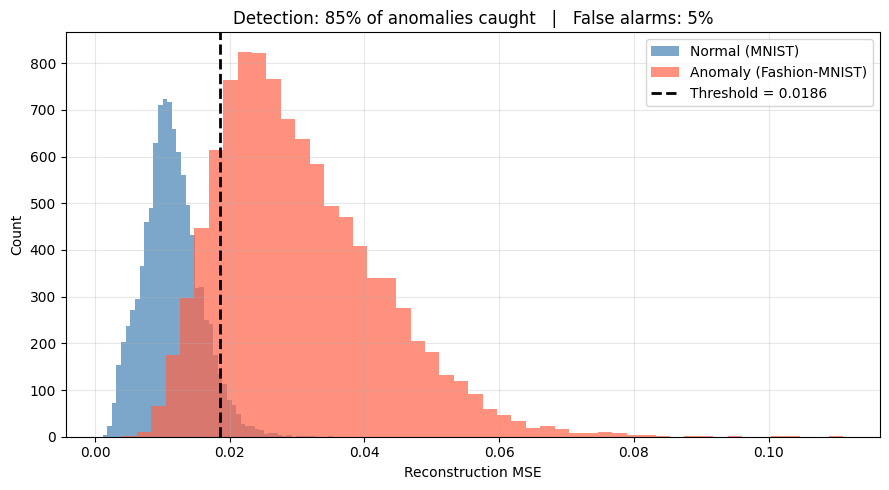

In [15]:
threshold = np.percentile(normal_errors.numpy(), 95)

flagged_normal = (normal_errors > threshold).sum().item()
flagged_anomaly = (anomaly_errors > threshold).sum().item()

false_alarm_rate = flagged_normal / len(normal_errors)
detection_rate = flagged_anomaly / len(anomaly_errors)

print(f"Threshold (95th percentile of normal): {threshold:.6f}\n")
print(f"  Normal  (MNIST):         {flagged_normal:5d} / {len(normal_errors)} above threshold  ({false_alarm_rate:.1%} false alarm)")
print(f"  Anomaly (Fashion-MNIST): {flagged_anomaly:5d} / {len(anomaly_errors)} above threshold  ({detection_rate:.1%} detection rate)")

# Histogram with threshold line
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(normal_errors.numpy(), bins=50, alpha=0.7, label="Normal (MNIST)", color='steelblue')
ax.hist(anomaly_errors.numpy(), bins=50, alpha=0.7, label="Anomaly (Fashion-MNIST)", color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f"Threshold = {threshold:.4f}")
ax.set_xlabel("Reconstruction MSE")
ax.set_ylabel("Count")
ax.set_title(f"Detection: {detection_rate:.0%} of anomalies caught   |   False alarms: {false_alarm_rate:.0%}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Visual Comparison: Noisy Input → Denoised Output → Clean Target

For MNIST the AE should denoise well (its output looks like a clean digit).
For Fashion-MNIST it has nothing sensible to denoise toward — output stays blurry or wrong.

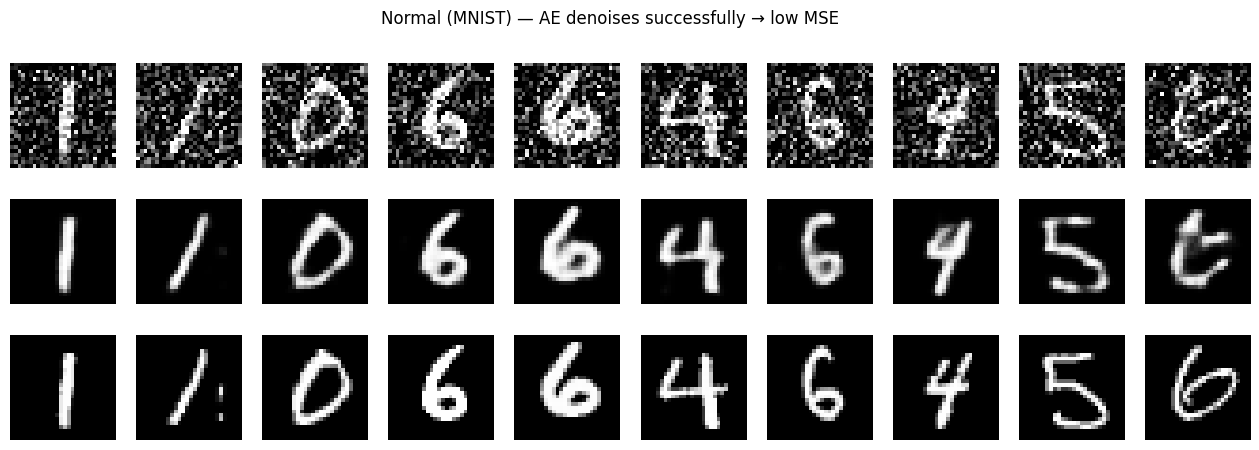

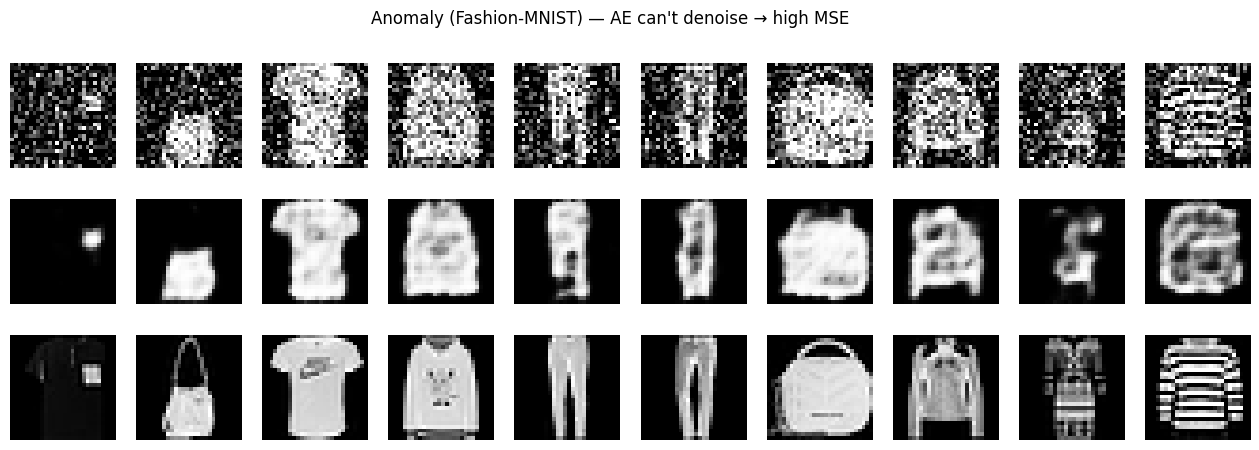

In [16]:
def show_denoise_row(clean, noisy, recons, errors, title, n=10):
    sorted_idx = errors.argsort()
    pick = sorted_idx[np.linspace(0, len(sorted_idx)-1, n, dtype=int)]

    fig, axes = plt.subplots(3, n, figsize=(1.6 * n, 5))
    for j, idx in enumerate(pick):
        axes[0, j].imshow(noisy[idx].squeeze(), cmap='gray');  axes[0, j].axis('off')
        axes[1, j].imshow(recons[idx].squeeze(), cmap='gray'); axes[1, j].axis('off')
        axes[2, j].imshow(clean[idx].squeeze(), cmap='gray');  axes[2, j].axis('off')
        axes[2, j].set_xlabel(f"{errors[idx]:.3f}", fontsize=7)
    axes[0, 0].set_ylabel("Noisy input", fontsize=10)
    axes[1, 0].set_ylabel("Denoised", fontsize=10)
    axes[2, 0].set_ylabel("Clean target", fontsize=10)
    plt.suptitle(title, fontsize=12)
    #plt.tight_layout()
    plt.show()

show_denoise_row(normal_clean, normal_noisy, normal_recons, normal_errors,
                  "Normal (MNIST) — AE denoises successfully → low MSE")
show_denoise_row(anomaly_clean, anomaly_noisy, anomaly_recons, anomaly_errors,
                  "Anomaly (Fashion-MNIST) — AE can't denoise → high MSE")